### Tensor
similar to List but an Object and Helps in Keeping Track. Just similar to torch.Tensor at core

In [37]:
import numpy as np
class Tensor:
    def __init__(self, data, children=(), op='', label=''):
        self.data = np.atleast_2d(np.asarray(data))
        self.label = label
        self.grad = np.asarray(np.zeros(shape=(self.data.shape)))
        #Internal variable for in
        self._op = op
        self._prev = children
        self._backward = lambda:None

    def __repr__(self):
        return f"Tensor :{self.data}"

    def __mul__(self, other):
        try:
            if not isinstance(other, Tensor):
                other = Tensor(other)

            if other.data.shape == (1, 1) and self.data.shape[1] != other.data.shape[0]:
                return self.elementwise_mul(other)


            # print("dims Self",self.data.shape,"dims other: ", (other.data.shape))
            out = Tensor(
                data = np.matmul(self.data, other.data),
                children=(self, other),
                op='*'
            )
            def _backward():
                self.grad += np.matmul(out.grad, other.data.swapaxes(-1, -2))
                other.grad += self.unbroadcast(np.matmul(self.data.swapaxes(-1,-2), out.grad),other.data.shape)

            out._backward = _backward
            return out
        except Exception as e:
            raise ValueError(
                f"Matrix multiplication failed: self dimensions {self.data.shape}, "
                f"other dimensions {other.data.shape}"
            ) from e

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Tensor(np.pow(self.data,other), children=(self,), op=f'**{other}')
        def _backward():
            self.grad += (other * np.pow(self.data,other-1)) * out.grad

        out._backward = _backward
        return out

    def exp(self):
        out = Tensor(np.exp(self.data),children=(self,), op="exp")

        def _backward():
            self.grad += out.data * out.grad  #element wise multiplication
        out._backward = _backward
        return out

    def transpose(self):
        out = Tensor(np.array(self.data).transpose(),op='T',children=(self,))
        def _backward():
            self.grad += out.grad.transpose()
        out._backward = _backward
        return out

    def softmax(self) -> 'Tensor':
        shifted = self.data - np.max(self.data, axis=1, keepdims=True)
        exp_shifted = np.exp(shifted)
        softmax_data = exp_shifted / np.sum(exp_shifted, axis=1, keepdims=True)

        out = Tensor(softmax_data, op='softmax', children=(self,))

        def _backward():
            # correct softmax Jacobian, per row:
            # dL/dx_i = s_i * (dL/dout_i - sum_j(s_j * dL/dout_j))
            s = out.data
            dot = np.sum(s * out.grad, axis=1, keepdims=True)
            self.grad += s * (out.grad - dot)

        out._backward = _backward
        return out

    def relu(self):
        b = self.data
        out = Tensor(np.where(np.greater_equal(0, b), 0, b),children=(self,),label='ReLU')

        def _backward():
            self.grad += (out.data>0)*out.grad

        out._backward = _backward
        return out

    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)


        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = np.asarray(np.ones(shape=(self.data.shape)))

        for v in reversed(topo):
            v._backward()

    def __sub__(self, other): # self - other
        return self + (-other)

    def __neg__(self): # -self
        return self * -1

    def __rmul__(self, other): #__rmul__ is used by python when a * b can't be calculated then python tries b * a
        return self*other

    def __radd__(self, other): # other + self
        return self + other

    def cat(tensors:list['Tensor'], axis = -1):
        if not isinstance(tensors, (list, tuple)):
            raise TypeError("cat() expects a list or tuple of Tensor objects")
        if len(tensors) == 0:
            raise ValueError("cat() requires at least one tensor")
        if not all(isinstance(t, Tensor) for t in tensors):
            raise TypeError("All elements in tensors must be Tensor instances")
        if len(tensors)==1: return tensors[0]

        out_data = np.concatenate([t.data for t in tensors],axis=axis)

        out = Tensor(out_data,
           children=tuple(tensors),
            op="cat"
        )
        def _backward():
            start = 0
            for t in tensors:
                size = t.grad.shape[axis]
                end = start + size
                idx = [slice(None)] * out.grad.ndim
                idx[axis] = slice(start,end)
                t.grad += out.grad[tuple(idx)]
                start = end
        out._backward = _backward
        return out

    def unbroadcast(self,grad, shape, label=''):
        # Remove extra dimensions on the left
        while grad.ndim > len(shape):
            grad = np.sum(grad, axis=0)
        # Sum dimensions where original shape was 1
        for axis, size in enumerate(shape):
            if size == 1 and grad.shape[axis] != 1:
                grad = np.sum(grad, axis=axis, keepdims=True)
        return grad

    def __add__(self, other):
        if not isinstance(other, Tensor):
            other = Tensor(other)
        out = Tensor(np.add(self.data, other.data), children=(self, other), op='+')
        def _backward():
            # print("trying to add: ", other.grad, out.data.shape)
            self.grad += self.unbroadcast(out.grad, self.data.shape)
            other.grad += self.unbroadcast(out.grad, other.data.shape)
        out._backward = _backward

        return out

    def elementwise_mul(self, other):
        if not isinstance(other, Tensor):
            other = Tensor(other)
        out = Tensor(
            data=self.data * other.data,
            children=(self, other),
            op='ew*'
        )
        def _backward():
            self.grad +=  self.unbroadcast(other.data * out.grad, shape=self.data.shape)
            other.grad += self.unbroadcast(self.data * out.grad, shape=other.data.shape)
        out._backward = _backward
        return out

    def mean(self,axis=1):
        out = Tensor(np.mean(self.data, axis=axis,keepdims=True),children=(self,),op='mean')
        def _backward():
            if axis is None:
                # If mean is taken over all elements, gradient is distributed equally
                self.grad += out.grad / self.data.size
            else:
                # If mean is taken over a specific axis
                self.grad += (1/self.data.shape[axis])*out.grad
        out._backward = _backward
        return out

    def std(self,axis = 1):
        out = Tensor(np.std(self.data,axis=axis,keepdims=True),children=(self,),op='std')
        def _backward():
            self.grad = out.grad * (self.data - np.mean(self.data)) / (self.data.shape[axis] * out.data)
        out._backward = _backward
        return out

    def tanh(self):
        e = self.elementwise_mul(2).exp()
        out = Tensor(
            (e - 1).data * ((e + 1)**-1).data,
            children=(self,),
            op='tanh'
        )

        def _backward():
            self.grad += out.grad * (1 - out.data**2)

        out._backward = _backward
        return out
    def log(self):
        out = Tensor(np.log(self.data), children=(self,), op='log')

        def _backward():
            self.grad += out.grad / self.data

        out._backward = _backward
        return out
    def sum(self, axis=1):
        out = Tensor(np.sum(self.data, axis=axis, keepdims=True,dtype=float), children=(self,), op='sum')
        
        def _backward():
            self.grad += np.ones_like(self.data) * out.grad  # broadcast grad back to original shape
        
        out._backward = _backward
        return out

### Graphvis for visualisation

In [34]:
%%script false --no-raise-error

!pip install graphviz
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})

    def matrix_html(matrix):
        matrix = np.atleast_2d(matrix)
        rows = []
        for row in matrix:
            cells = ''.join(
                f'<TD BORDER="1" CELLPADDING="4">{value:.4g}</TD>'
                for value in row
            )
            rows.append(f'<TR>{cells}</TR>')
        return (
            '<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0">'
            + ''.join(rows) +
            '</TABLE>'
        )

    for n in nodes:
        label = (
            f'<<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0">'
            f'<TR><TD><B>{n.label}</B></TD></TR>'
            f'<TR><TD>{matrix_html(n.data)}</TD></TR>'
            f'<TR><TD>grad</TD></TR>'
            f'<TR><TD>{matrix_html(n.grad)}</TD></TR>'
            f'</TABLE>>'
        )

        dot.node(
            name=str(id(n)),
            label=label,
            shape='plain'
        )

        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

def draw_graph(end_targate):
    end_targate.backward()
    dot = draw_dot(end_targate)
    dot.body[:] = [
        line.replace("<B></B>", "<B>&#160;</B>")
        for line in dot.body
    ]
    dot.render()
    display(dot)


### Multi layer perceptron
created Neuron --> Layer --> MLP

In [ ]:
from typing import Literal
import random
import warnings


class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = np.zeros_like(p.data)

    def parameters(self):
        return []


class Neuron(Module):
    def __init__(self, m_features, non_linear=True,activation_fn: Literal["tanh", "relu"] = "relu"):
        std = np.sqrt(2 / m_features)       
        self.W = Tensor(np.random.randn(m_features,1) * std,label="w")

        self.b = Tensor([[0.0]],label="bias")

        self.non_linear = non_linear
        self.activation_fn = activation_fn

    def __call__(self, x):

        # x is expected to be:
        # (batch_size, m_features)

        x = Tensor(np.asarray(x, dtype=float)) if not isinstance(x, Tensor) else x

        # for matmul (x,W) == (n_inp, p_words, m_features),(m_features,1) --> (n_inp,p_words,1)
        
        # print(((x.data.shape),self.W.data.shape))
        act = ( x * self.W ) + self.b

        # Return matmul shape: (n_inp, p_words, 1)
        # Final layer: return raw logits
        if not self.non_linear:
            out = act
            return out

        # Hidden layer activation
        activation = getattr(act, self.activation_fn)
        return activation()

    def parameters(self):
        return [self.W, self.b]

    def __repr__(self):
        activation = self.activation_fn if self.non_linear else "linear"
        return f"{activation} Neuron({self.W.data.shape[1]})"


class Layer(Module):
    def __init__(self,layer_id,m_features,n_out,activation_fn="relu",non_linear=True):
        self.layer_id = layer_id

        self.neurons = [Neuron(m_features=m_features,activation_fn=activation_fn,non_linear=non_linear) for _ in range(n_out)]

    def __call__(self, x):

        # Each neuron produces:(n_inp,p_words,1) * L neuron .Cat --> (n_inp,p_words, L )
        outputs = [neuron(x) for neuron in self.neurons]
        outputs = Tensor.cat(outputs, axis=-1)
        return outputs

    def parameters(self):
        return [ p for neuron in self.neurons for p in neuron.parameters()]

    def __repr__(self):
        return (f"Layer of " f"[{', '.join(str(n) for n in self.neurons)}]")


class MLP(Module):

    def __init__( self, m_features: int, Layer_outs: list[int], activation_fn="relu"):
        input_size = [m_features] + Layer_outs
        self.layers = [
            Layer(
                layer_id=i,
                m_features=input_size[i],
                n_out=input_size[i + 1],

                # Hidden layers -> activation
                # Final layer -> linear
                non_linear=(i != len(Layer_outs) - 1),
                

                activation_fn=activation_fn
            )
            for i in range(len(Layer_outs))
        ]

    def predict(self, x):

        # Convert input to Tensor once
        if not isinstance(x, Tensor):
            x = Tensor(np.asarray(x, dtype=float))

        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [ p for layer in self.layers for p in layer.parameters()]

    def Fit(
        self,
        x,
        y,
        epoch=200,
        lr=0.0001,
        batch_size=32,
        loss_type: Literal["mse", "cross_entropy"] = "mse"
    ):
        n = len(y)
        epoch_loss_history = []

        for _ in range(epoch):

            # Shuffle every epoch
            indices = list(range(n))
            random.shuffle(indices)

            epoch_loss = 0.0
            num_batches = 0

            for start in range(0, n, batch_size):

                batch_indices = indices[start:start + batch_size]

                x_batch = [x[i] for i in batch_indices]
                y_batch = [y[i] for i in batch_indices]

                # Forward pass
                ypred = self.predict(x_batch)

                # Convert target to Tensor
                y_tensor = (
                    y_batch
                    if isinstance(y_batch, Tensor)
                    else Tensor(np.asarray(y_batch, dtype=float), label="Output")
                )

                # Check shape
                if y_tensor.data.shape != ypred.data.shape:
                    raise ValueError(
                        "Prediction and target shape mismatch: "
                        f"y.shape={y_tensor.data.shape}, "
                        f"ypred.shape={ypred.data.shape}"
                    )

                # Forward + backward + update
                loss = self._GradientDescent(
                    y=y_tensor,
                    ypred=ypred,
                    lr=lr,
                    loss_type=loss_type
                )
                # Store scalar loss
                epoch_loss += float(np.asarray(loss.data).mean())
                num_batches += 1

            # Average batch losses
            epoch_loss_history.append(epoch_loss / num_batches)

        return epoch_loss_history


    def _GradientDescent(self, y, ypred, loss_type, lr=0.1):

        # Convert y to Tensor
        if not isinstance(y, Tensor):
            y = Tensor(
                np.asarray(y, dtype=float),
                label="Output"
            )

        # Reset gradients
        for p in self.parameters():
            p.grad = np.zeros_like(p.data)

        # Calculate loss
        loss = self._Calculate_Loss(
            ypred=ypred,
            y=y,
            loss_type=loss_type
        )

        # Backprop
        loss.backward()

        # Gradient descent
        for p in self.parameters():
            p.data -= lr * p.grad

        return loss


    def _Calculate_Loss(self, ypred: Tensor, y: Tensor, loss_type):

        if loss_type == "mse":

            # Element-wise squared error
            squared_error = (ypred - y) ** 2
            # Mean over all elements
            return squared_error.mean()

        elif loss_type == "cross_entropy":

            warnings.warn(
                "Using binary cross entropy."
            )

            # Ignore labels == -100
            mask = Tensor(
                (np.asarray(y.data) != -100).astype(float)
            )

            # Replace ignored labels with 0
            target = Tensor(
                np.where(
                    np.asarray(y.data) == -100,
                    0,
                    np.asarray(y.data)
                )
            )

            eps = 1e-7

            # IMPORTANT:
            # Don't do `ypred += eps`
            # because that modifies the prediction Tensor in-place.
            safe_ypred = ypred + eps

            # BCE:
            #
            # -[y log(p) + (1-y) log(1-p)]
            #
            positive = target.elementwise_mul(safe_ypred.log())

            negative = (
                Tensor(1.0) - target
            ).elementwise_mul(
                (Tensor(1.0) - safe_ypred).log()
            )

            loss = (positive + negative).elementwise_mul(mask)

            # Average only valid elements
            number_of_valid = mask.sum()

            return loss.elementwise_mul(
                number_of_valid ** -1
            ).sum()

        else:
            raise ValueError(
                f"Unknown loss type: {loss_type}"
            )
            
    def __repr__(self):
        return (
            f"MLP of "
            f"[{', '.join(str(layer) for layer in self.layers)}]"
        )
        


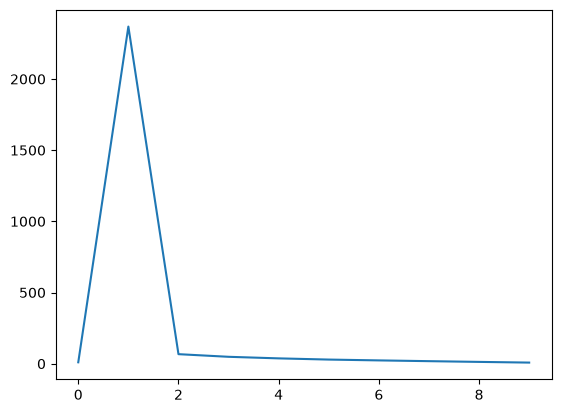

In [53]:

# #[ sentence1-->[3 words--> [word1(1x96)][word2][word3]]
# #  sentence2-->[[word1][word2][word3]]
# #  sentence3-->[[word1][word2][word3]] ]
# #shape = [3, 3, 96]
word_embeds = [[[
    [[0.6972834, 0.08725786, -0.1506938, -0.67638519],[-1.30838017, -1.7098192, -1.44106524, -1.63344123]],
    [[0.6972834, 0.08725786, -0.1506938, -0.67638519],[-1.30838017, -1.7098192, -1.44106524, -1.63344123]],
    [[0.6972834, 0.08725786, -0.1506938, -0.67638519],[-1.30838017, -1.7098192, -1.44106524, -1.63344123]],
    ]]]
#word_embeds_shape = [3,3,3]
word_embeds_id = [[[
  [[-0.04213773], [-6.09270584]],
  [[-0.04213773], [-6.09270584]],
  [[-0.04213773], [-6.09270584]],
]]]

model  = MLP(m_features=np.shape(word_embeds)[-1], Layer_outs=[32,32,1],activation_fn='relu')
loss = model.Fit(word_embeds,word_embeds_id,epoch=10,batch_size = 1,lr=0.01)
import matplotlib.pyplot as plt
plt.plot(loss)

### Transformer

In [36]:
import numpy as np
# from .backprop import Tensor

def sinusoidal_positional_encoding(m_words:int, n_dims:int):
    #number of words, n_dims = embedding dims of each word
    #P_E(pos,2i) = sin(pos/10000^(2i/n_dims))
    #P_E(pos,2i+1) = cos(pos/10000^(2i/n_dims))

    #division term = position/10000^(2i/n_dims) = position * 10000^-(2i/n_dims) = position * e^(-2*position*log(10000)/n_dims)
    position = np.arange(m_words)[:,np.newaxis]
    div_term = np.exp(-2*position*np.log(10000)/n_dims)

    pos_embed = np.zeros(shape=(m_words,n_dims))
    #even position
    pos_embed[:,0::2] = np.sin(position*div_term)
    pos_embed[:,1::2] = np.cos(position*div_term)
    pos_embed = Tensor(pos_embed,label='pos_embed')
    return pos_embed

def layer_normalize(matrix:list):
    # matrix = multihead attention embedding [mxn]
    constant = 0.001 # to preven from being zero at denominator
    l2 = np.array(matrix)
    mean = np.mean(l2,axis=1,keepdims=True)[:,np.newaxis] #returns [mX1]
    x_minus_mean = l2 - mean
    var = np.sqrt(np.mean(np.square(x_minus_mean),axis=1)[:,np.newaxis] + constant) #[mx1]

    normalized = x_minus_mean/var
    return normalized

class attention_head:
    def __init__(self, shape: tuple[int, int] = (1, 1)):
        self.m, self.n = shape
        self.W_q = Tensor(np.random.randn(self.n,self.n),label='w_q')
        self.W_k = Tensor(np.random.randn(self.n,self.n),label='w_k')
        self.W_v = Tensor(np.random.randn(self.n,self.n),label='w_v')

    def __call__(self, P_E:Tensor):
        # """Attention"""
        Q = P_E * self.W_q
        K = P_E * self.W_k
        V = P_E * self.W_v
        div_factor = Tensor(1/np.sqrt(self.n))
        similarity = div_factor.elementwise_mul(Q * K.transpose())
        context_embed:Tensor = (similarity * V).softmax() # softmax((1/sqrt(dk))*Q.K)*V

        # """Add and Norm"""
        context_embed = context_embed + P_E
        return context_embed
    def perameter(self):
        return self.W_q,self.W_k,self.W_v


class Transformer:
    def __init__(self,word_embeds:list,activation_fn, n_heads:int = 8, ):
        self.word_embeds = Tensor(word_embeds,label='Data ingestion')
        print("Data Ingestion Successfull, Shape: ", self.word_embeds.data.shape)
        self.m,self.n = np.shape(self.word_embeds.data)
        self.n_heads = n_heads #number of attention head
        std = np.sqrt(2 / self.n)       
        self.W_multi_head = Tensor(np.random.randn(self.n*n_heads, self.n) * std,label="multihead")
        self.all_attention_heads = [attention_head(shape=(self.m,self.n)) for _ in range(self.n_heads)]
        self.lr = 0.01
        # """ FFN Model """

    def encoder(self):
        pos_encode:Tensor = sinusoidal_positional_encoding(self.m,self.n)
        P_E = self.word_embeds.__add__(pos_encode)  #P_E = positional encoding

        # Multi head attention

        tensors = [head(P_E) for head in self.all_attention_heads]
        multi_head_attention:Tensor = Tensor.cat(tensors) * self.W_multi_head
        add = multi_head_attention + P_E
        add = add -add.mean()
        add_n_norm = add.elementwise_mul(add.std()**-1); add_n_norm.label = 'add n norm'


        # """ Feed Forward Neural Network """
        # model = self.model
        # FFNN1:list[Tensor] = model(add_n_norm)

        # add_n_norm2 = add_n_norm + Tensor.cat(FFNN1)
        return add_n_norm

    def initialse_model(self, activation_fn):
        valid_activations = {"tanh", "relu"}
        if activation_fn not in valid_activations:
            raise ValueError(f"activation_fn must be one of {valid_activations}")
        model = MLP(n_inp=self.n, Layer_outs=[64, 64, 32, self.n],activation_fn=activation_fn)
        return model

    def Perameter(self):
        params = [self.W_multi_head]
        for head in self.all_attention_heads:
            params.extend(head.perameter())
        params.extend(self.model.parameters())
        return params

# Data Prep

In [38]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt

In [39]:
#Read csv-------------------
# %%script false --no-raise-error
df = pd.read_csv('../database/Reddit_Data.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


#### Preprocessing

In [40]:
# %%script false --no-raise-error

print(df.info())
print("Target data distribution: ",[int((i/37249)*100) for i in df.category.value_counts()])


df.dropna(inplace=True)
print("Total null Values: ",df.isnull().sum())
#lower casing
df['clean_comment'] = df['clean_comment'].str.lower()

#remove punctuation
import string
exclude = string.punctuation
print(exclude)
def removepunc(text:str):
    return text.translate(str.maketrans('','',exclude))

df['clean_comment'] = df['clean_comment'].apply(removepunc)
df.head()

#stop word removal
# !pip install nltk
import nltk
from nltk.corpus import stopwords
import time
nltk.download('stopwords')
en_stopwords = stopwords.words('english')

def removestopwords(text:str):
    newword = []
    for word in text.split():
        if word not in en_stopwords:
            newword.append(word)
    x = newword[:]
    newword.clear()
    return " ".join(x)

df['clean_comment'] = df.clean_comment.apply(removestopwords)

#emoji replacement with their meaning
# !pip install emoji
import emoji
df.clean_comment = df.clean_comment.apply(emoji.demojize)


#Nltk not that accurate but for now, just use it
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
df.clean_comment = df.clean_comment.apply(word_tokenize)
df.head()

from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
def stem_word(text_row):
    return (" ".join(ps.stem(word) for word in text_row))
df.clean_comment = df.clean_comment.apply(stem_word)
df.head(1)



<class 'pandas.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   clean_comment  37149 non-null  str  
 1   category       37249 non-null  int64
dtypes: int64(1), str(1)
memory usage: 582.1 KB
None
Target data distribution:  [42, 35, 22]
Total null Values:  clean_comment    0
category         0
dtype: int64
!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


/home/nishant/Documents/ml_projects/youtube_extension/.venv/lib/python3.14/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/nishant/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/nishant/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/home/nishant/Documents/ml_projects/youtube_extension/.venv/lib/python3.14/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/nishant/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] D

,clean_comment,category
0,famili mormon never tri explain still stare pu...,1


#### Vocab Preparing for bert like Model Training

In [41]:
# %%script false --no-raise-error
df['split_comment'] = df.clean_comment.str.split()
df.head()

,clean_comment,category,split_comment
0,famili mormon never tri explain still stare pu...,1,"[famili, mormon, never, tri, explain, still, s..."
1,buddhism much lot compat christian especi cons...,1,"[buddhism, much, lot, compat, christian, espec..."
2,serious say thing first get complex explain no...,-1,"[serious, say, thing, first, get, complex, exp..."
3,learn want teach differ focu goal wrap paper b...,0,"[learn, want, teach, differ, focu, goal, wrap,..."
4,benefit may want read live buddha live christ ...,1,"[benefit, may, want, read, live, buddha, live,..."


In [42]:
# %%script false --no-raise-error
unique_words = set()
for comment_words in df['split_comment']:
    unique_words.update(comment_words)

vocabulary = ['[PAD]', '[CLS]','[UNK]', '[SEP]', '[MASK]'] + list(unique_words)
word_to_id = {word: idx for idx, word in enumerate(vocabulary)}

# Display a sample of the created word_to_id mapping and its size
print(f"Vocabulary size: {word_to_id}")


Vocabulary size: {'[PAD]': 0, '[CLS]': 1, '[UNK]': 2, '[SEP]': 3, '[MASK]': 4, 'dxafnw0': 5, 'delicaci': 6, 'cours': 7, 'mayanti': 8, 'prescient': 9, 'laalbatti': 10, 'jockey': 11, 'yeha': 12, 'pahal': 13, 'ox3mw0rlxgikxxctkhbwxk': 14, 'competit': 15, 'parivaar': 16, 'event': 17, 'clapham': 18, 'st': 19, 'setexittransit': 20, 'disaffect': 21, 'acknowled': 22, 'kumbh': 23, 'paaji': 24, 'akimirksniuj': 25, 'miscreant': 26, 'surveyor': 27, 'stepbroth': 28, 'interessa': 29, 'khu': 30, 'duplic': 31, 'healthiest': 32, 'jay': 33, 'dst': 34, 'khairiat': 35, 'speedi': 36, 'affrontar': 37, 'mati': 38, 'tangent': 39, 'yaad': 40, 'rpa': 41, 'khana': 42, 'motherf': 43, 'janmana': 44, 'turkey': 45, 'tenth': 46, 'symptom': 47, 'wipe': 48, 'ubiquit': 49, '438077': 50, 'pagalbo': 51, 'sep': 52, 'ir': 53, 'niekada': 54, 'princecharlesi': 55, 'oldretardarch': 56, 'gostando': 57, 'soilder': 58, 'vadh': 59, 'saviour': 60, 'claimant': 61, 'oratory1990': 62, 'pater': 63, 'aborigene': 64, 'senthil': 65, 'você

### Sentence to Vector

### Masking + Length Equilizing

In [43]:
# %%script false --no-raise-error
import random

def mask_input_rows(x: list, mask_prob=0.15):
    # Sentence words to Vector
    #all sentence doesn't have equal length:  It needs equal length: 94% of data las len<64; I'll use it as base trunket greater then this
    word_to_vec = [word_to_id[word] for word in x]
    word_to_vec = word_to_vec[:62]+ [word_to_id['[SEP]']] if len(word_to_vec) > 62 else word_to_vec+ [word_to_id['[SEP]']] + [word_to_id['[PAD]']] * (62 - len(word_to_vec))
    sentence_vec = [word_to_id['[CLS]']] + word_to_vec

    labels = [-100] * len(sentence_vec)  # if its not -100 get the -log(prediction) if the prediction is lower --> high loss else low loss

    for index in range(1, len(sentence_vec) - 1):  # skip CLS (0) and SEP (last)
        if random.random() < mask_prob:
            labels[index] = sentence_vec[index]  # store original id as label

            r = random.random()
            if r < 0.8:
                sentence_vec[index] = word_to_id['[MASK]']
            elif r < 0.9:
                sentence_vec[index] = random.randint(0, len(word_to_id) - 1)
            # else: leave unchanged (10%), label still set above

    return sentence_vec, labels

df[['Masked_Sentence_Vec', 'Labels']] = df['split_comment'].apply(lambda x: pd.Series(mask_input_rows(x)))
df.head()


,clean_comment,category,split_comment,Masked_Sentence_Vec,Labels
0,famili mormon never tri explain still stare pu...,1,"[famili, mormon, never, tri, explain, still, s...","[1, 39069, 25144, 844, 13419, 17722, 109, 6893...","[-100, -100, -100, -100, -100, -100, -100, -10..."
1,buddhism much lot compat christian especi cons...,1,"[buddhism, much, lot, compat, christian, espec...","[1, 32335, 30817, 37243, 14883, 9457, 36299, 2...","[-100, -100, -100, -100, -100, -100, -100, -10..."
2,serious say thing first get complex explain no...,-1,"[serious, say, thing, first, get, complex, exp...","[1, 20045, 37575, 31279, 28105, 36764, 31146, ...","[-100, -100, -100, -100, -100, -100, -100, -10..."
3,learn want teach differ focu goal wrap paper b...,0,"[learn, want, teach, differ, focu, goal, wrap,...","[1, 4, 19590, 39841, 4, 23846, 33622, 4, 2296,...","[-100, 33411, -100, -100, 23919, -100, -100, 2..."
4,benefit may want read live buddha live christ ...,1,"[benefit, may, want, read, live, buddha, live,...","[1, 24729, 18653, 19590, 37982, 19601, 10115, ...","[-100, -100, -100, -100, -100, -100, -100, -10..."


In [44]:
# %%script false --no-raise-error
from sklearn.model_selection import train_test_split
x = df['Masked_Sentence_Vec']
y = df['Labels']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)


print(x_train.shape)
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)



(29719,)
x_train: (29719,)
x_test: (7430,)
y_train: (29719,)
y_test: (7430,)


### Model Sanity Test

In [45]:
#simple XOR Sanity test
x = [[0,0],[0,1],[1,0],[1,1]]
y = [[0],[1],[1],[0]]
model  =  MLP(n_inp=2,Layer_outs=[32,32,1],activation_fn='relu')
lossH = model.Fit(x,y,epoch=100,batch_size =4,lr=0.001,loss_type='mse',)
print(lossH)


[1.515101865741756, 1.2113305984197569, 0.9931248782639939, 0.8396908201414772, 0.7219271773589095, 0.6301290041257669, 0.5587301658888761, 0.5016183922090812, 0.45522294640198013, 0.41632345071011123, 0.38378046747877326, 0.35618500212465937, 0.3324769638915151, 0.3124217437651234, 0.29533404781008554, 0.2793471934291823, 0.26614558567490954, 0.2530494411519599, 0.2422041287536972, 0.23127808724895701, 0.22186991452021665, 0.2126664118188023, 0.2041367783474668, 0.1963540396513137, 0.18855721705116163, 0.18162111683690405, 0.17477986363245607, 0.16812287749013102, 0.1621928162990224, 0.15617265304418781, 0.15036579807544434, 0.1451227305114764, 0.13984071733818526, 0.13471132093784247, 0.12997372541926472, 0.12535863361116228, 0.12079412690042851, 0.11679886188954101, 0.1132870887037995, 0.10968503658643655, 0.10648029215088543, 0.10357325038490597, 0.10071806427381809, 0.0978544068722542, 0.0950798322514349, 0.09257861232188397, 0.08996979175631849, 0.08742998375804845, 0.08499686034

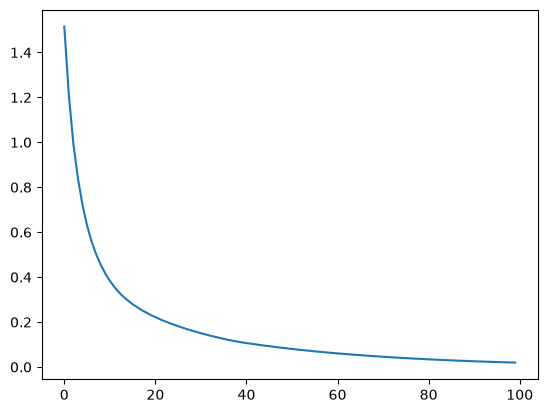

In [ ]:
import matplotlib.pyplot as plt
plt.plot(lossH)